# ILUSTR 3 — Szereg Taylora: informacja zakodowana w pochodnych i błąd odcięcia

Pokrywa: slajdy 81–83 prezentacji ZW_1 („Szereg Taylora — przypomnienie") oraz sekcję
„Twierdzenie Taylora i szereg Taylora" konspektu (w tym implikacje praktyczne).

**Istota twierdzenia Taylora:** o funkcji w punkcie $a$ wiadomo tylko to, co da się
wyrazić przez jej wartość i pochodne w TYM JEDNYM punkcie. Każda pochodna to jedna
„porcja informacji" o kształcie funkcji:

- $f(a)$ — gdzie funkcja **jest** (poziom, przesunięcie pionowe),
- $f'(a)$ — dokąd **zmierza** (nachylenie, kierunek),
- $f''(a)$ — jak się **zakrzywia** (wypukłość, zwrot przyspieszenia),
- $f^{(3)}(a)$ — jak zmienia się samo zakrzywienie...

$$f(x) \;\approx\; \underbrace{f(a)}_{\text{poziom}} + \underbrace{f^{(1)}(a)(x{-}a)}_{\text{kierunek}}
+ \underbrace{\tfrac{f^{(2)}(a)}{2}(x{-}a)^2}_{\text{zakrzywienie}} + \underbrace{\tfrac{f^{(3)}(a)}{6}(x{-}a)^3}_{\text{zmiana zakrzywienia}} + \ldots$$

Skoro każda pochodna mówi coś nowego o kształcie, to **każdy następny składnik poprawia
przybliżenie w coraz szerszym otoczeniu** punktu $a$. Cały wykład o metodach numerycznych
opiera się na tym obrazku: metody różniczkowania, całkowania i równań różniczkowych to
zorganizowane sposoby korzystania z lokalnej informacji z pochodnych.

Druga strona tego samego medalu: skoro liczymy tylko skończoną liczbę składników, to zawsze
pozostaje **błąd odcięcia** (zaniechane wyrazy szeregu). Zobaczymy jego strukturę na dwóch
przeciwstawnych funkcjach: e$^x$ i $1/(1+x^2)$.

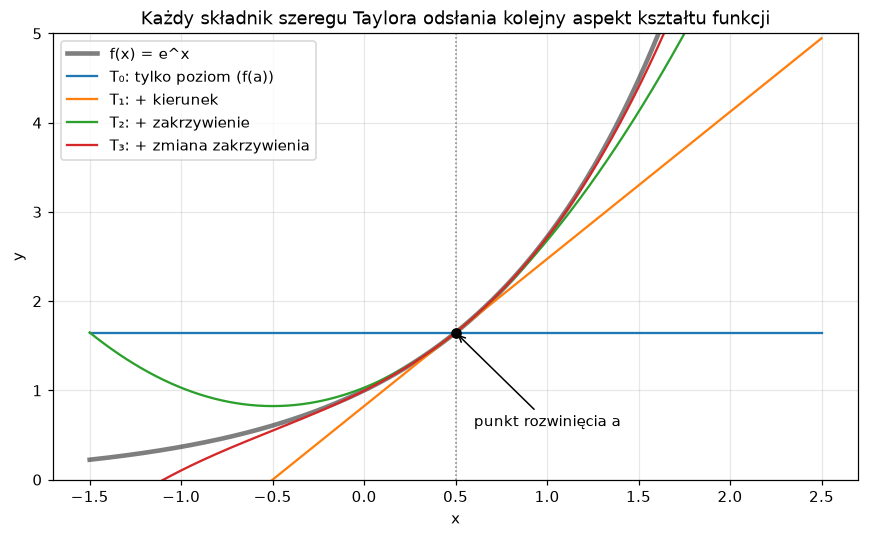

In [2]:
# Demo 1: budowanie przybliżenia od zera — po kolei dokładamy składniki.
import numpy as np
import matplotlib.pyplot as plt

a = 0.5                                   # punkt rozwinięcia
x = np.linspace(-1.5, 2.5, 400)

f = np.exp(a)                             # f(a)
d1 = f                                    # f'(a) dla e^x
d2 = f                                    # f''(a) = f(a) dla e^x
d3 = f
h = x - a

T0 = np.full_like(x, f)
T1 = T0 + d1*h
T2 = T1 + d2/2 * h**2
T3 = T2 + d3/6 * h**3

plt.figure(figsize=(8, 5))
plt.plot(x, np.exp(x), 'k', lw=3, alpha=.5, label='f(x) = e^x')
plt.plot(x, T0, lw=1.5, label='T₀: tylko poziom (f(a))')
plt.plot(x, T1, lw=1.5, label='T₁: + kierunek')
plt.plot(x, T2, lw=1.5, label='T₂: + zakrzywienie')
plt.plot(x, T3, lw=1.5, label='T₃: + zmiana zakrzywienia')
plt.axvline(a, color='gray', ls=':', lw=1)
plt.scatter([a], [f], color='k', zorder=5)
plt.annotate('punkt rozwinięcia a', (a, f), xytext=(a+0.1, 0.6),
             arrowprops=dict(arrowstyle='->'))
plt.ylim(0, 5); plt.xlabel('x'); plt.ylabel('y')
plt.title('Każdy składnik szeregu Taylora odsłania kolejny aspekt kształtu funkcji')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# Kluczowa obserwacja: przy a przybliżenia przylegają do funkcji jak "przyklejone",
# ale w miarę oddalania się od a kolejne składniki odklejają się w kolejności —
# pierwsza odpada T0 (stała), potem T1 (prosta), itd. 

## Czym jest „wystarczająco dokładnie" w otoczeniu punktu: promień użyteczności

Konspekt podkreśla: nawet jeden składnik opisuje funkcję dostatecznie dokładnie **w pewnym
otoczeniu** punktu $a$. Ale jak duże jest to otoczenie? Odpowiedź jest różna dla różnych
funkcji — i to jest druga połowa istoty twierdzenia Taylora:

- dla $e^x$ kolejne pochodne są łagodne (wszystkie równe $e^a$), szereg zbiega wszędzie,
- dla $f(x) = \sin(x)$ też zbiega wszędzie,
- dla $f(x) = 1/(1+x^2)$ szereg rozwinięty w $a=0$ zbiega **tylko w promieniu $|x|<1$**
  — choć funkcja jest idealnie gładka na całej osi! (Przypadek Rungego znany z rozdziału
  o interpolacji — tu wraca w czystej postaci analitycznej.)

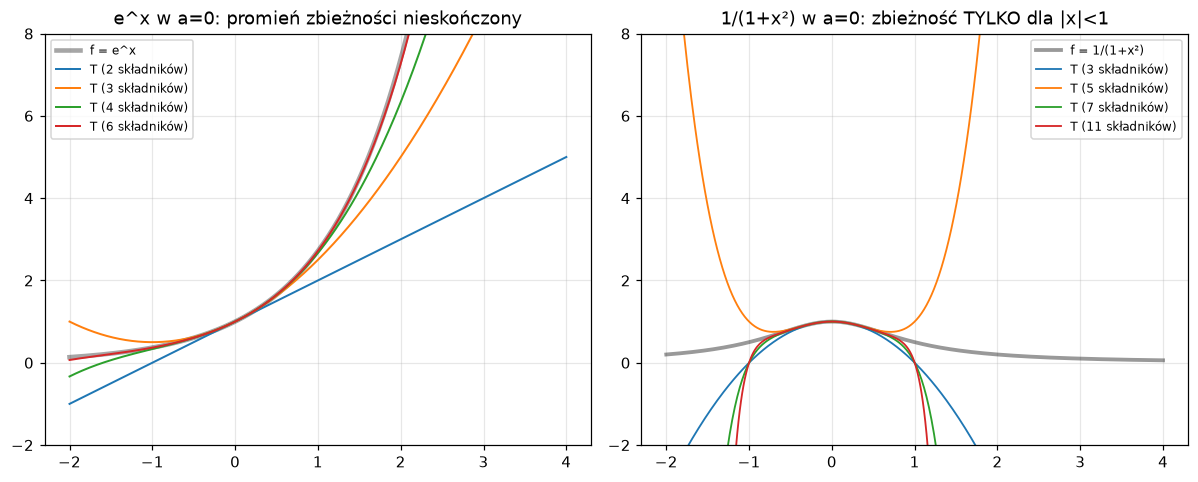

In [4]:
# Demo 2: dwa charakterystyczne promienie zbieznosci.
# e^x rozwiniete w a=0: dodajemy skladniki -> zbiega wszedzie.
# 1/(1+x^2) rozwiniete w a=0: zbiega tylko dla |x| < 1.
import numpy as np
from math import factorial
import matplotlib.pyplot as plt

x = np.linspace(-2, 4, 400)
plt.figure(figsize=(11, 4.5))

# --- lewy panel: e^x w a=0 ---
plt.subplot(1, 2, 1)
plt.plot(x, np.exp(x), 'k', lw=3, alpha=.35, label='f = e^x')
S = np.zeros_like(x)
for n in range(0, 6):                    # pochodne e^x w 0: wszystkie rowne 1
    S = S + 1/factorial(n) * x**n
    if n in (1, 2, 3, 5):
        plt.plot(x, S, lw=1.3, label=f'T ({n+1} składników)')
plt.ylim(-2, 8); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.title('e^x w a=0: promień zbieżności nieskończony')

# --- prawy panel: 1/(1+x^2) w a=0 ---
plt.subplot(1, 2, 2)
plt.plot(x, 1/(1+x**2), 'k', lw=2.5, alpha=.4, label='f = 1/(1+x²)')
S = np.zeros_like(x)
for k, n in enumerate(range(0, 12, 2)):  # 1 - x^2 + x^4 - x^6 + ...
    S = S + (-1)**k * x**n
    if n in (2, 4, 6, 10):
        plt.plot(x, S, lw=1.2, label=f'T ({n+1} składników)')
plt.ylim(-2, 8); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.title('1/(1+x²) w a=0: zbieżność TYLKO dla |x|<1')

plt.tight_layout(); plt.show()

# Mechanizm: jedynki w liczniku i (1+x²) w mianowniku — bieguny zespolone ±i w odległości 1
# od a=0 blokują zbieżność szeregu, mimo gładkości na osi rzeczywistej. Poza |x|>1
# kolejne składniki ROŚNĄ bez ograniczenia: przybliżenie nie poprawia się, tylko wali.

## Wielomian odtwarzony dokładnie — i co z tego wynika dla liczenia

Konspekt podkreśla dwie implikacje praktyczne:

1. **Wielomian stopnia $W$ odtworzy dokładnie suma $W{+}1$ składników** — wyższe pochodne
wielomianu są zerowe, więc dalsze składniki szeregu znikają. Sprawdzimy to na wielomianie,
który na pierwszy rzut oka niczym nie przypomina e$^x$.
2. **Błąd odcięcia** — pominięte wyrazy to w pełni przewidywalny koszt przybliżenia;
   to on odróżnia „metodę" od „prawdy" i to jemu metody numeryczne starają się minimalizować
   bez rozbijania budżetu obliczeniowego.

In [6]:
# Demo 3: wielomian stopnia W == jego własny szereg Taylora (W+1 składnikow).
import numpy as np
x = np.linspace(-1.5, 1.5, 300)
W = 4                                   # stopien wielomianu
# przykladowy wielomian stopnia 4: p(x) = x^4 - 2x^3 + 3x^2 - x + 0.5
p  = lambda x: x**4 - 2*x**3 + 3*x**2 - x + 0.5
# pochodne w punkcie a=0: p(0)=0.5, p1(0)=-1, p2(0)=6, p3(0)=-12, p4(0)=24
a = 0.0
poch = [0.5, -1, 6, -12, 24]            # kolejne pochodne w a=0
from math import factorial
T = np.zeros_like(x)
bledy = []
for n, d in enumerate(poch):
    T = T + d/factorial(n) * x**n
    bledy.append(np.abs(T - p(x)).max())

print("Liczba uwzględnionych składników -> maksymalny błąd na [-1.5,1.5]:")
for n, err in enumerate(bledy, start=1):
    print(f"  {n} " + ("składnik:" if n == 1 else "składniki:") + f" {err:.2e}")
print()
print("Po 5 składnikach błąd spada do zera DOKŁADNIE (dalsze pochodne wielomianu znikają).")
print("To twierdzenie o maksymalnym stopniu: wielomian == własny szereg Taylora.")

Liczba uwzględnionych składników -> maksymalny błąd na [-1.5,1.5]:
  1 składnik: 2.01e+01
  2 składniki: 1.86e+01
  3 składniki: 1.18e+01
  4 składniki: 5.06e+00
  5 składniki: 3.55e-15

Po 5 składnikach błąd spada do zera DOKŁADNIE (dalsze pochodne wielomianu znikają).
To twierdzenie o maksymalnym stopniu: wielomian == własny szereg Taylora.


e^2: najmniejszy błąd 2.40e-16 — przy 23 składnikach
     to 1.1 x eps64: dalej błąd odcięcia ginie w zaokrągleniach
Ostatni uwzględniony składnik: 2^22/22! = 3.73e-15

Punkt kluczowy: poniżej eps64 błąd odcięcia jest NIEOBCIĄŻALNY w arytmetyce
float64 — dalsze składniki giną w zaokrągleniach. Dlatego 'dokładność maszyny'
wyznacza, kiedy przestać liczyć: to naturalna granica błędu METODY.


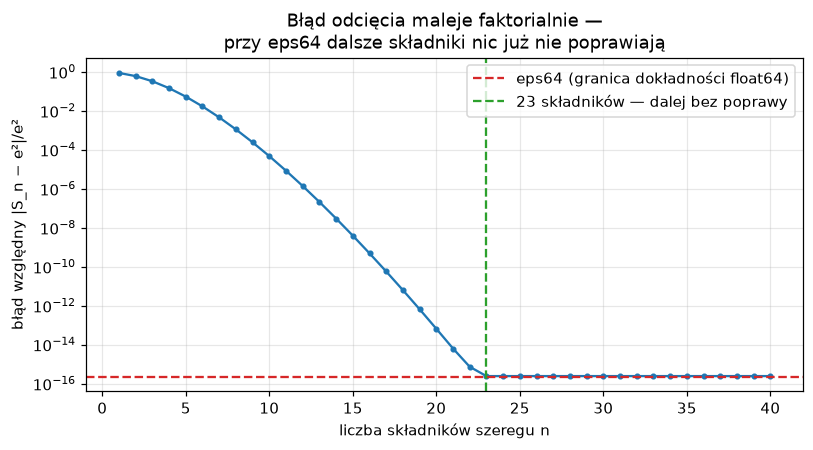

In [7]:
# Demo 4: błąd odcięcia w praktyce — ile składników trzeba, żeby osiągnąć eps maszynowy?
import math
# e^2 liczony sumą: ile składników daje pełną dokładność float64?
cel = math.exp(2.0)
S, historia = 0.0, []
for n in range(0, 40):
    S += 2.0**n / math.factorial(n)
    historia.append(abs(S - cel))
# pierwsze n, przy którym błąd <= eps64 = 2.22e-16 (względny)
eps64 = 2.22e-16
rel = [e/cel for e in historia]
n_dokl = int(np.argmin(rel))   # blad przestaje mniejszac: poziom zaokraglen

plt.figure(figsize=(7.5, 4.2))
plt.semilogy(range(1, 41), rel[:40], 'o-', ms=3, color='tab:blue')
plt.axhline(eps64, color='tab:red', ls='--', label='eps64 (granica dokładności float64)')
plt.axvline(n_dokl+1, color='tab:green', ls='--', label=f'{n_dokl+1} składników — dalej bez poprawy')
plt.xlabel('liczba składników szeregu n'); plt.ylabel('błąd względny |S_n − e²|/e²')
plt.title('Błąd odcięcia maleje faktorialnie —\nprzy eps64 dalsze składniki nic już nie poprawiają')
plt.legend(); plt.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

print(f"e^2: najmniejszy błąd {rel[n_dokl]:.2e} — przy {n_dokl+1} składnikach")
print(f"     to {rel[n_dokl]/eps64:.1f} x eps64: dalej błąd odcięcia ginie w zaokrągleniach")
print(f"Ostatni uwzględniony składnik: 2^{n_dokl}/{n_dokl}! = {2.0**n_dokl/math.factorial(n_dokl):.2e}")
print()
print("Punkt kluczowy: poniżej eps64 błąd odcięcia jest NIEOBCIĄŻALNY w arytmetyce")
print("float64 — dalsze składniki giną w zaokrągleniach. Dlatego 'dokładność maszyny'")
print("wyznacza, kiedy przestać liczyć: to naturalna granica błędu METODY.")

## Najważniejsze wnioski

- Każdy składnik szeregu Taylora odsłania kolejną cechę kształtu funkcji (poziom → kierunek
  → zakrzywienie → …); im więcej składników, tym szersze otoczenie dobrego przybliżenia.
- Promień użyteczności zależy od funkcji: e$^x$ — wszędzie; $1/(1+x^2)$ — tylko $|x|<1$
  (bieguny zespolone blokują zbieżność mimo gładkości na osi rzeczywistej).
- Wielomian stopnia $W$ to jego własny szereg Taylora: $W{+}1$ składników odtwarza go dokładnie.
- **Błąd odcięcia** to zaniechane wyrazy szeregu — jest przewidywalny i maleje faktorialnie;
  poniżej eps maszynowego dalsze składniki giną w zaokrągleniach, więc nie ma sensu ich liczyć.
- Metody numeryczne różnią się od prawdy dokładnie błędem odcięcia — dlatego każda metoda
  ma swój wzór na ten błąd (zob. rozdziały o różniczkowaniu i całkowaniu).

In [9]:
# ĆWICZENIE (szkielet — uzupełnij miejsca oznaczone TODO):
#
# 1) Rozwiń f(x) = ln(x) w punkcie a=1 i policz T_1, T_2, T_3 ręcznie na kartce;
#    sprawdź numerycznie, że T_3 błądzi mniej niż T_1 na przedziale [0.5, 1.5].
x = np.linspace(0.5, 1.5, 100)
T1 = None    # TODO: (x-1)
T3 = None    # TODO: (x-1) - (x-1)**2/2 + (x-1)**3/3
# print(np.abs(T1-np.log(x)).max(), np.abs(T3-np.log(x)).max())

# 2) Ile składników potrzeba, żeby przybliżyć e^2 na [0.5, 4] w a=0.5 do błędu
#    względnego 1%? A ile do eps64? Policz i skomentuj różnicę względem rysunku wyżej
#    (promień rozwinięcia a=0.5 jest bliżej x=2, ale zasada pozostaje ta sama).

# 3) Zabierz jedną jedynkę: przybliż 1/(1+x^2) szeregiem w punkcie a=0 na [0, 1.2]
#    i zmierz błąd przy |x| = 0.9 i |x| = 1.1. Dlaczego po przekroczeniu promienia
#    przybliżenie nie tylko nie poprawia się, ale się PSUJE z każdym składnikiem?


## Wykorzystywane funkcje

- `math.factorial(n)` — silnia we współczynnikach $f^{(n)}(a)/n!$,
- `np.linspace`, `plt.semilogy` — standardowe narzędzia rysowania; skala logarytmiczna
  pokazuje zbieżność do eps64 na kilka rzędów wielkości naraz.

## Ćwiczenie — wskazówki

1) pochodne ln(x) w a=1: $f^{(n)}(1) = (-1)^{n+1}(n{-}1)!$, więc $T_3 = h - h^2/2 + h^3/3$,
   gdzie $h = x-1$.
2) analogicznie do Demo 4, tylko $x^n \to (x{-}a)^n$ i pochodne $e^{0.5} \cdot 1$ —
   policz najmniejsze $n$ spełniające warunek na każdym $x$ z przedziału.
3) policz wartości szeregu w 1.1 dla rosnącego $n$ — zobacz, że $|T_n|$ rośnie; mechanizm
   to współczynniki $(-x^2)^k$, które dla $x^2>1$ mają rosnące wartości bezwzględne.